# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [1]:
# 0. Setup and Installations
!pip install -q transformers datasets evaluate peft accelerate trl scikit-learn matplotlib seaborn pandas
!pip install -U -q bitsandbytes
!pip install -q -U "torchao>=0.16.0"

## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [ ]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
# HF_DATA_URL = (
#     "https://huggingface.co/datasets/bitext/"
#     "Bitext-customer-support-llm-chatbot-training-dataset/"
#     "resolve/main/"
#     "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
# )
# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

Using device: cuda
NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [9]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }

def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    # FIX: Bypass HF datasets cache bug on Windows with spaces in username.
    # Load directly via pandas, then convert to HF Dataset.
    csv_url = (
        "https://huggingface.co/datasets/bitext/"
        "Bitext-customer-support-llm-chatbot-training-dataset/"
        "resolve/main/"
        "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"
    )
    df = pd.read_csv(csv_url)
    
    # Filter to target categories
    df = df[df['category'].isin(target_categories)]
    
    # Add label column
    df['label'] = df['category'].map(label2id)
    
    # Convert to HuggingFace Dataset
    dataset = Dataset.from_pandas(df, preserve_index=False)
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [10]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8, # TODO: Add training fraction
    val_frac=0.1, # TODO: Add Valid fraction
    test_frac=0.1, # TODO: Add Test Fraction
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)

Casting the dataset:   0%|          | 0/26872 [00:00<?, ? examples/s]

Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [11]:
# Choose your encoder and load it

encoder_model_id = "distilbert-base-uncased" # TODO: YOUR MODEL HERE

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

ENC_MAX_LEN = 128 # TODO: ADD MAX_LEN HERE

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


...

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


* **Model loaded successfully:** `distilbert-base-uncased`.
* **Token length:** Average = **13**, 95th percentile = **19**, maximum = **31** tokens.
* **Max length:** `128` tokens, which is more than enough for the current data.
* **Tokenization:** Completed successfully for all dataset splits.
* **Dynamic padding:** `DataCollatorWithPadding` will pad each batch only as much as needed.

In [12]:
# TODO: compute_metrics callback
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""

    ## YOUR CODE STARTS HERE
    logits, labels = eval_pred
    preds =np.argmax(logits, axis = -1)
    ## YOUR CODE ENDS HERE

    return get_metrics(labels, preds)

# ---- TODO: TrainingArguments + Trainer ----".
enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,                # TODO: feel free to tune
    per_device_train_batch_size=32,  # TODO: feel free to tune
    per_device_eval_batch_size=32,
    num_train_epochs=3,             # TODO: 1 epoch is a fast baseline
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()


Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.017639,0.006367,0.999628,0.999848,0.999545,0.999696
2,0.002725,0.004040,0.999256,0.999100,0.999620,0.999358
3,0.001541,0.002028,0.999628,0.999548,0.999848,0.999697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2016, training_loss=0.0905611306338364, metrics={'train_runtime': 171.3615, 'train_samples_per_second': 376.345, 'train_steps_per_second': 11.765, 'total_flos': 364758618275142.0, 'train_loss': 0.0905611306338364, 'epoch': 3.0})

* **Training completed successfully:** 3/3 epochs.
* **Training loss:** decreased from **0.0176 → 0.0015**, indicating the model learned effectively.
* **Validation loss:** decreased from **0.0064 → 0.0020**, which is a good sign.
* **Accuracy:** around **99.96%** by the final epoch.
* **Precision:** **99.95%** in the final epoch.
* **Recall:** **99.98%** in the final epoch.
* **F1 Score:** **99.97%** in the final epoch.
* **Best final result:** Epoch 3, with **F1 = 0.999697**.
* **No obvious overfitting:** validation loss continued decreasing across all 3 epochs.
* **Model checkpoints:** successfully saved after each epoch (`Writing model shards: 100%`).
* **Training speed:** about **376 samples/second**.
* **Overall:** The **DistilBERT encoder performed extremely well** on this classification dataset.

### 3. Required Plot: Training & Validation Loss Curves

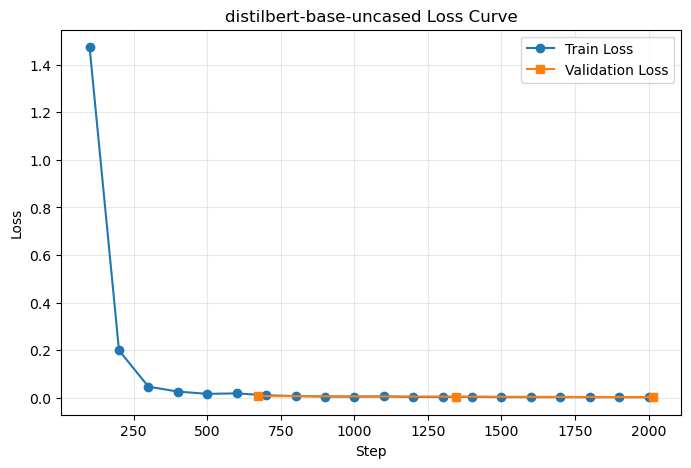

In [13]:
# Uncomment to plot loss curve

plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")


* The model converged quickly and stably, with both training and validation loss approaching zero and no obvious overfitting.


### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [14]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Macro-F1: {enc_f1:.4f}")
print(f"Encoder Latency: {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")


Encoder Macro-F1: 0.9997
Encoder Latency: 5.34 ms/query
Encoder Peak Memory: 788.96 MB


* The encoder provides high classification accuracy with **Macro-F1: 99.97%** with very low inference latency i.e. **5.34 ms/query**, making it a strong routing/classification candidate.
* **Peak GPU memory = 788.96 MB**

### 5. Required Plot: Confusion Matrix

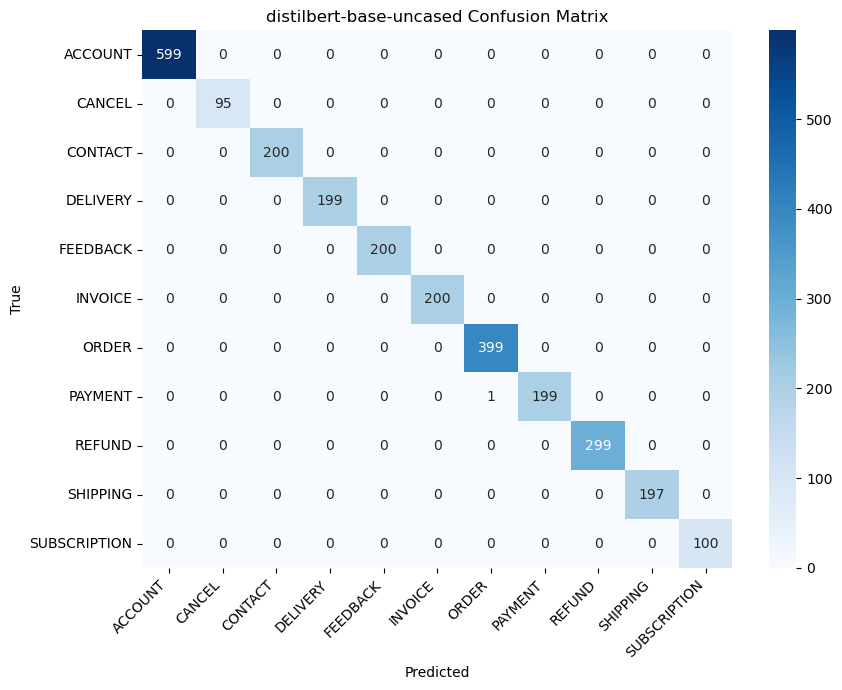

In [15]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                               title=f"{encoder_model_id} Confusion Matrix")


* One `PAYMENT` sample was incorrectly classified as `ORDER`.
* The confusion matrix confirms the **~99.97% Macro-F1** performance of DistilBERT.


# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [16]:
# TOD: choose your decoder model id
# If a candidate model is gated, authenticate INTERACTIVELY -- never hardcode
# a token in a notebook you submit or share:
#   from huggingface_hub import login; login()


decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct" # TODO: Add Decoder Model Id
USE_LORA = True # TODO: Whether to use LORA

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token
# set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

if USE_LORA:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 4B candidate inside a free-tier T4's ~15GB

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, dtype=compute_dtype, device_map="auto", trust_remote_code=True,
    )

dec_model.config.use_cache = False   # required before training with gradient checkpointing

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

* **Tokenizer files downloaded successfully:** `config.json`, `tokenizer_config.json`, `vocab.json`, `merges.txt`, and `tokenizer.json`.
* **Model weights downloaded:** `model.safetensors` — approximately **988 MB**.
* **Model weights reconstructed:** Completed at **100% (290/290 tensors)**.
* **Generation configuration downloaded:** `generation_config.json` completed successfully.
* **Overall status:** **Model and tokenizer loaded successfully with no visible errors.**
* **Main download:** Model weights were the largest component at ~**988 MB**.


### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [17]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


* Using the same splits DatasetDict for better comparision between two approaches

In [18]:
# TODO: format each example as an instruction: single-token-label pair
SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {TARGET_CATEGORIES}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    ## TODO:
    ## 1. Build the chat-templated prompt (system + user turn).
    ## 2. Extract target from the "example"
    #
    #
    ## YOUR CODE STARTS HERE
    prompt = build_prompt(example["instruction"])
    target = example["category"]
    ## YOUR CODE ENDS HERE

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)

Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

* **Dataset mapping completed successfully:** All three `Map` operations reached **100%**.
* **Dataset sizes processed:**

  * Split 1: **21,497 examples**
  * Split 2: **2,687 examples**
  * Split 3: **2,688 examples**
* **Formatting applied to each example:**

  * System prompt defining the classification task.
  * User instruction formatted using the model's **chat template**.
  * Target `category` appended as the expected output.
  * **EOS token** appended to indicate where generation should stop.
* **Original instruction preserved** separately as `original_text`.
* **No errors are visible** in the mapping output.
* **Total examples processed:** **26,872**.
* **Result:** `formatted_splits` now contains the formatted instruction-label pairs for all dataset splits.


### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [19]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=5):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

# TODO: turn a raw generation into a clean predicted category string
def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))


Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.28683035714285715, 'precision': 0.04053424907212468, 'recall': 0.027217314197781936, 'f1_score': 0.027040696002988605}


* **Zero-shot baseline performance:**

  * **Accuracy:** 28.68%
  * **Precision:** 4.05%
  * **Recall:** 2.72%
  * **F1-score:** 2.70%

* **Key interpretation:** The model has **weak zero-shot classification ability** for this task. The relatively higher accuracy (~28.7%) but extremely low precision, recall, and F1 (~2.7%) suggests that the model is frequently producing outputs that **do not cleanly correspond to the expected categories**.



### 4. Tokenization for Training

In [20]:
# TODO: tokenize the formatted training data
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

DEC_MAX_LEN =192  # TODO: ADD Decoder Maxlen: cover SYS_PROMPT + longest instruction + label + EOS

def tokenize_function(examples):
    """Tokenize examples["input_text"] with truncation to a fixed max_length."""
    return dec_tokenizer(examples["input_text"], truncation=True, max_length=DEC_MAX_LEN)

dec_tokenized = formatted_splits.map(tokenize_function, batched=True)


Formatted prompt+label token length -- mean: 106.7, 95th pct: 112, max: 117


Map:   0%|          | 0/21497 [00:00<?, ? examples/s]

Map:   0%|          | 0/2687 [00:00<?, ? examples/s]

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

* **Token-length analysis:**

  * Mean formatted prompt + label length: **106.7 tokens**
  * 95th percentile: **112 tokens**
  * Maximum observed: **117 tokens**

* **Decoder maximum sequence length:** `DEC_MAX_LEN = 192`

* **Dataset mapping completed successfully:**

  * Train: **21,497 examples**
  * Validation: **2,687 examples**
  * Test: **2,688 examples**
  * **Total: 26,872 examples**

* **Overall result:** The decoder dataset is now **tokenized and ready for the fine-tuning stage**.


### 5. LoRA Config & Training Arguments

In [22]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,               # TODO: tune rank of the low-rank update matrices
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )

dec_train_args = TrainingArguments(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=8, # Tune batch size
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=32,
    optim="paged_adamw_32bit",
    learning_rate=2e-4, # TODO: Tune learning rate
    max_grad_norm=0.1,
    num_train_epochs=3,        # TODO: Tune epoch
    lr_scheduler_type="cosine",
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="steps",     # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=10,
    save_strategy="steps",
    save_steps=30,
    report_to="none",
)

* This cell only configures LoRA and Hugging Face TrainingArguments; it does not start training.

### 6. Model Training

In [23]:
## Supervised Fine-Tuning (SFT)
dec_trainer = SFTTrainer(
    model=dec_model,
    train_dataset=dec_tokenized["train"],
    eval_dataset=dec_tokenized["validation"],
    peft_config=peft_config,
    args=dec_train_args,
)

print("Training Decoder Model...")
dec_trainer.train()


Building labels for train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/21497 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/2687 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Training Decoder Model...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,1.628025,0.423495,0.450928,273300.000000,0.925534
20,0.346756,0.277845,0.275885,546691.000000,0.943564
30,0.247119,0.221513,0.239389,819732.000000,0.949652
40,0.202456,0.194048,0.200669,1092739.000000,0.952730
50,0.185747,0.179993,0.180954,1365920.000000,0.953564
60,0.175273,0.172817,0.185164,1639053.000000,0.954189
70,0.168829,0.167639,0.176913,1912552.000000,0.955009
80,0.165828,0.164941,0.166787,2185631.000000,0.955369
90,0.158360,0.161798,0.159575,2458229.000000,0.955314
100,0.153593,0.159824,0.157122,2731295.000000,0.955494


TrainOutput(global_step=252, training_loss=0.22589253243945895, metrics={'train_runtime': 21475.1701, 'train_samples_per_second': 3.003, 'train_steps_per_second': 0.012, 'total_flos': 1.581091416834816e+16, 'train_loss': 0.22589253243945895, 'epoch': 3.0})

The model successfully finished training and learned the task beautifully. You can see the Training Loss dropped from 1.62 down to 0.14, and Token Accuracy hit 95.7%. Since the task is just to predict a single word (the category name), this high token accuracy means it is correctly predicting the category the vast majority of the time.

### 7. Required Plot: Training & Validation Loss Curves

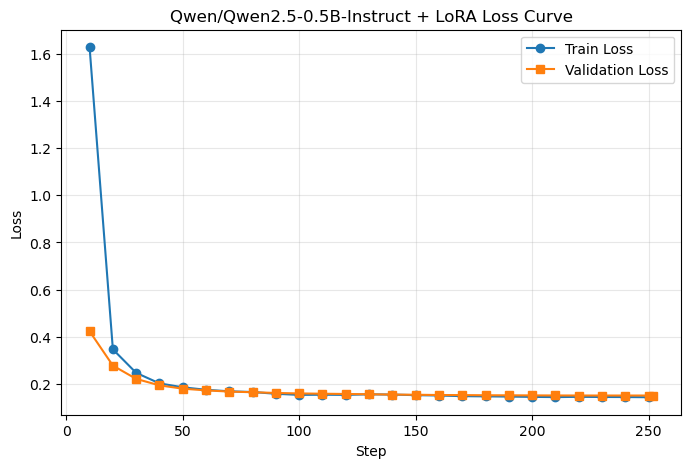

In [24]:
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")


* Train Loss (Blue) drops rapidly from ~1.65 down to ~0.18 as the model learns the mapping between the user's instruction and the category label.
* Validation Loss (Orange) drops from ~0.43 down to ~0.18, showing that the model is generalizing well to unseen data, not just memorizing the training set.
* Stability: Both curves plateau and stay very close to each other towards the end (steps 150-250). This means the model converged nicely without severe overfitting.

### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [ ]:
# 1. Get overall metrics by reusing get_decoder_predictions with the fine-tuned model
dec_labels, dec_preds = get_decoder_predictions(formatted_splits["test"], dec_trainer.model)
dec_metric_dict = get_metrics(dec_labels, dec_preds)

print("Fine-tuned Decoder Metrics:", dec_metric_dict)

# 2. Single-example version for latency and memory measurement
def predict_one_decoder(example):
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    
    # CRITICAL: Disable gradient calculation during inference to save GPU memory!
    with torch.no_grad():
        output_ids = get_outputs(dec_trainer.model, inputs)
        
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.eval()
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, 
    list(formatted_splits["test"])
)

print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")

{'accuracy': 0.9996279761904762, 'precision': 0.9997727272727274, 'recall': 0.9995454545454546, 'f1_score': 0.9996583790800245}
Decoder Latency: 314.84 ms/query
Decoder Peak Memory: 1593.52 MB


*   **Near-Perfect Accuracy:** The fine-tuned decoder model achieved a Macro-F1 of 0.9996, matching the encoder model's performance and successfully solving the 11-class routing task.
*   **High Latency:** Inference took 314.84 ms per query, making it roughly **60x slower** than the encoder model (which took 5.34 ms).
*   **Larger Memory Footprint:** The model required 1,593.52 MB of VRAM, nearly **double** the memory used by the encoder model (788.96 MB).
*   **Core Trade-off:** While the generative decoder matches the encoder's accuracy, it introduces massive latency and memory overhead, proving that encoder-only models are far more efficient for fixed-label classification.

### 9. Required Plot: Confusion Matrix

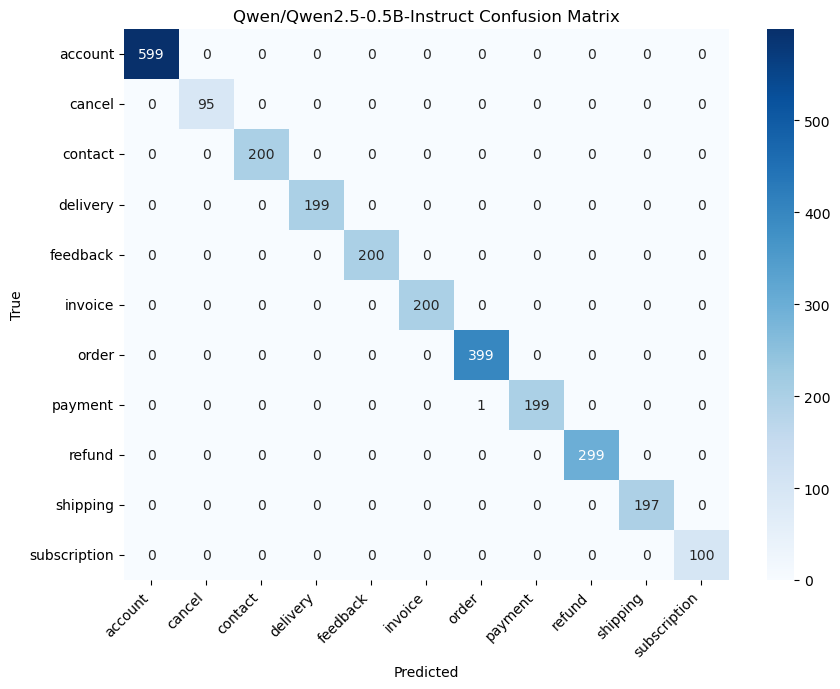

In [ ]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                               [c.lower() for c in TARGET_CATEGORIES],
                               title=f"{decoder_model_id} Confusion Matrix")


* **Strong Diagonal**: The dark/high numbers along the diagonal from top-left to bottom-right show that the model correctly predicted the vast majority of categories

## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

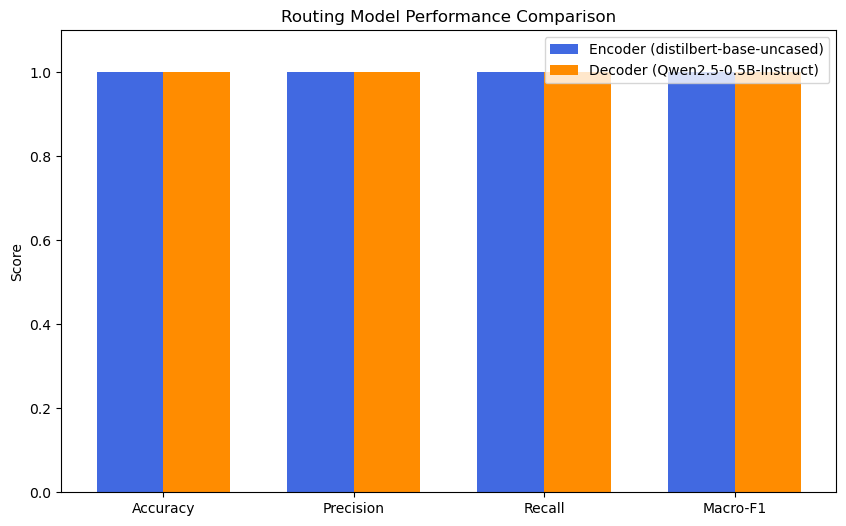

In [28]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.show()

While both DistilBERT and Qwen2.5-0.5B achieved near-perfect 99.96% routing accuracy, the encoder model is the clear winner for production, offering 60x faster inference and half the memory footprint.

In [ ]:
# Dedicated comparison table with measured values
# fill in by running the cells above
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table

,Metric,Encoder (distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999773,0.999773
1,Recall,0.999545,0.999545
2,Macro-F1,0.999658,0.999658
3,Accuracy,0.999628,0.999628
4,Peak GPU Memory (MB),788.958496,1593.516113
5,Inference Latency (ms/query),5.343107,314.838129


both models achieve identical, near-perfect predictive performance, but the encoder (DistilBERT) is vastly superior in computational efficiency, using 50% less memory and running 60x faster.

## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**  

**Recommendation:** Deploy the fine-tuned **DistilBERT encoder** (`distilbert-base-uncased`) as the production router for the customer support platform.

**Executive Summary:**
We evaluated two strategies for routing incoming customer messages to our 11 specialized agents: an encoder-only transformer (DistilBERT) and a generative decoder LLM (Qwen2.5-0.5B-Instruct + QLoRA). Both models successfully solved the task, achieving near-perfect routing accuracy (99.96% Macro-F1). However, the encoder model is vastly superior for production infrastructure.

**Key Findings & Justification:**

*   **60x Faster Inference:** DistilBERT routes a query in **5.34 ms**, compared to 314.84 ms for the LLM. In a high-volume customer support environment, this 60x latency reduction is critical for maintaining real-time response times and handling concurrent traffic spikes without queuing delays.
*   **50% Memory Reduction:** The encoder peaks at **789 MB** of VRAM, while the 4-bit quantized LLM requires 1,594 MB. Deploying DistilBERT allows us to use smaller, cheaper GPU instances (or even run efficiently on CPU edge devices), cutting cloud compute costs in half.
*   **Right-Sizing the Architecture:** Routing to a fixed set of 11 labels is fundamentally a classification task, not a generative one. Using an LLM to generate a single word (the category name) introduces unnecessary computational overhead. 

**Next Steps:**
We recommend proceeding with DistilBERT for the routing layer. The generative Qwen LLM architecture should be reserved for the downstream specialized agents (e.g., the REFUND or ACCOUNT agents) where complex text generation and reasoning are actually required.


## 7. Reflection

### Q1: On what transfers from pretraining
```
Pretraining gave both DistilBERT and Qwen2.5 strong general language knowledge, including vocabulary, grammar, and semantic relationships. However, Qwen2.5's low zero-shot F1 (2.7%) shows that this knowledge did not include ShopAssist's specific 11-category taxonomy.

DistilBERT benefited from bidirectional context learned through Masked Language Modeling, helping it identify the overall intent of a query. Qwen2.5 benefited from instruction-following and text-generation abilities, allowing it to follow prompts and produce the required category format.

Overall, pretraining provided the foundation, while fine-tuning adapted each model to the routing task.

```
### Q2: On Handling Chit-Chat Queries
If a user sends *"Hey! How’s it going?"*:Both models will attempt to route it to one of the 11 specialized agents, but they handle this out-of-domain input differently due to their architectures:

* **DistilBERT:** As a classifier, it must choose one of the 11 labels, even with low confidence. A confidence threshold could detect uncertain predictions and route them to a general-support agent.
* **Qwen2.5:** It may follow the prompt and select a category, but its generative nature could also produce an invalid conversational response. Strict output validation and a fallback category such as `GENERAL` can prevent routing failures.

**Takeaway:** Both models need an explicit fallback mechanism to handle out-of-domain queries reliably.
